In [ ]:
import numpy as np
from enum import Enum
import math

class Modulation(Enum):
    BPSK = 1
    QPSK = 2
    QAM8 = 3
    QAM16 = 4

def get_eligible_modulation(reach):
    if reach > 2500:
        return [Modulation.BPSK]
    elif reach > 1250:
        return [Modulation.BPSK, Modulation.QPSK]
    elif reach > 625:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8]
    else:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8, Modulation.QAM16]
    
data_rate = 100
reach = 500
modulations = get_eligible_modulation(reach)
num_slots = [int(math.ceil(data_rate/(modulation.value * 12.5))) + 1 for modulation in modulations]
print(num_slots)
d = zip(modulations, num_slots)
for o in d:
    print(o)
# num_slots = int(np.ceil(data_rate / (modulations * 12.5))) + 1

In [ ]:
import numpy as np

alpha_dB: float = 0.2
L_span: float = 80.0
NF_dB: float = 5.0
G_dB = alpha_dB * L_span
G_lin = 10**(G_dB / 10)
NF_lin = 10**(NF_dB / 10)
n_sp = (NF_lin / 2) * (G_lin / (G_lin - 1))
alpha = alpha_dB * (np.log(10) / 10)
al = 10**(alpha_dB/10)
G_l = np.e**(alpha*L_span)
print(n_sp)
print(alpha, G_lin, G_l)

In [ ]:
from data.utility import read_network_file

filepath = "data/nsf/network.txt"
# def generate_request_set(filepath):
nodedf, adjacent = read_network_file(filepath)

[0.8017837257372732, 0.4008918628686366, 0, 0, 0, 0, 0.8017837257372732, 0.5345224838248488, 0.2672612419124244, 0, 0, 0.8017837257372732, 0.6013377943029549, 0.4008918628686366, 0.2004459314343183, 0, 0]


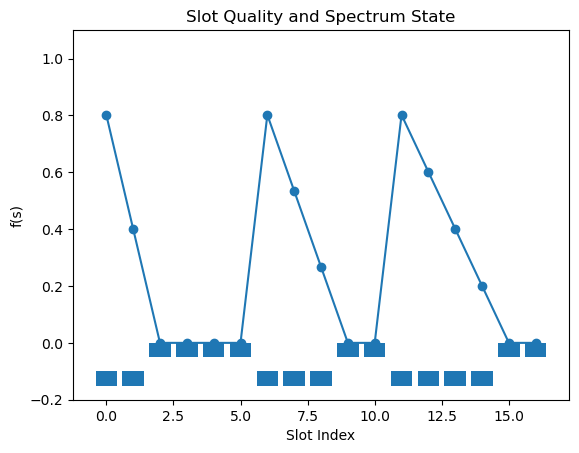

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

def F(slot_index, spectrum):
    available_block = []
    n = len(spectrum)
    i = 0
    if spectrum[slot_index] == 1:
        return 0
    
    a, b = 0, 0
    while i < n:
        if spectrum[i] == 0:
            start = i
            while i < n and spectrum[i] == 0:
                i += 1
            available_block.append((start, i - 1))
            if start <= slot_index and slot_index <= i-1:
                a = start
                b = i-1
        else:
            i += 1

    max_slot = max([e - s for s, e in available_block])
    sum_square = sum([(e - s)**2 for s, e in available_block])
    f = (b - slot_index + 1) / (b - a + 1) * max_slot / math.sqrt(sum_square)
    return f
            

spectrum = [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]
val = [F(i, spectrum) for i in range(len(spectrum))]
print(val)

fig, ax = plt.subplots()

# plot function values
x = np.arange(len(spectrum))
ax.plot(x, val, marker='o')
ax.set_xlabel("Slot Index")
ax.set_ylabel("f(s)")
ax.set_title("Slot Quality and Spectrum State")

# draw spectrum rectangles
for i, slot in enumerate(spectrum):

    if slot == 1:
        height = -0.05
    else:
        height = -0.15

    rect = plt.Rectangle((i - 0.4, height), 0.8, 0.05)
    ax.add_patch(rect)

ax.set_ylim(-0.2, 1.1)

plt.show()

In [1]:
from custom_env.optical_rl_gym.envs.rmsa_env import RMSAEnv
from custom_env.CustomRLenv.utils import get_topology, read_sndlib_txt_file


# topology = get_topology('./data/nsf/nsfnet_chen.txt', 'NSFNET')

topology = get_topology(f'./data/germany/sndlib_germany.txt', 'Germany', sndformat=True, k_paths=3)
env = RMSAEnv(topology, mean_service_holding_time=25)

# graph = read_sndlib_txt_file(f'./data/germany/sndlib_germany.txt')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


	 Path(path_id=0, node_list=['1', '47', '43', '25', '46', '48', '2'], hops=6, length=487, best_modulation=Modulation(name='16QAM', maximum_length=500, spectral_efficiency=4, minimum_osnr=22.4, inband_xt=-23), current_modulation=None)
	 Path(path_id=1, node_list=['1', '47', '43', '24', '25', '46', '48', '2'], hops=7, length=506, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=2, node_list=['1', '30', '29', '24', '25', '46', '48', '2'], hops=7, length=511, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=3, node_list=['1', '30', '29', '17', '19', '50', '38', '3'], hops=7, length=534, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=4, node_list=['1', '30', '29', 

In [2]:
path1 = topology.graph['ksp']['1', '8'][0]
path2 = topology.graph['ksp']['1', '8'][1]

env._provision_path(path1, 1, 20)

In [6]:
import numpy as np
# env.topology.graph["available_slots"]

print(path1, path2)

for i in range(len(path2.node_list) - 1):
    # if np.any(
    #     env.topology.graph["available_slots"][
    #         env.topology[path1.node_list[i]][path1.node_list[i + 1]]["index"],
    #         1 : 11,
    #     ]
    #     == 0
    # ):
    #     print(False)
    print(env.topology.graph["available_slots"][
            env.topology[path2.node_list[i]][path2.node_list[i + 1]]["index"],
            1 : 25,
        ])
    
# env._provision_path(path2, 1, 10)

Path(path_id=18, node_list=['1', '49', '39', '7', '8'], hops=4, length=394, best_modulation=Modulation(name='16QAM', maximum_length=500, spectral_efficiency=4, minimum_osnr=22.4, inband_xt=-23), current_modulation=None) Path(path_id=19, node_list=['1', '49', '15', '11', '36', '40', '39', '7', '8'], hops=8, length=431, best_modulation=Modulation(name='16QAM', maximum_length=500, spectral_efficiency=4, minimum_osnr=22.4, inband_xt=-23), current_modulation=None)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]


In [16]:
for e in topology.edges():
    print(topology.get_edge_data(e[0], e[1]))
    break

for n in topology.nodes():
    print(n)
    break

print(topology.nodes())

{'id': 8, 'index': 8, 'weight': 1, 'length': 61}
1
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50']


In [ ]:
def simulate(initial_damage, turn, percentage_bonus):
    for i in range(turn):
        initial_damage += initial_damage * 10/100

    return initial_damage + initial_damage*percentage_bonus

print("20%, 500 damage", simulate(500, 100, 20/100))
print("41%, 450 damage", simulate(450, 100, 41/100))


31%, 500 damage 9026301.08258359
62%, 450 damage 10046066.395730432
